In [65]:
pip install hmmlearn seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [66]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import random
import seaborn as sns
from scipy.stats import norm

Still wondering if capturing a different time period or having more observation will have a huge difference on the curves.

In [67]:
nvda = yf.download(
    "NVDA",
    start="2019-01-01",
    end="2026-02-18",
    progress=False
)

returns = np.log(nvda["Close"]).diff().dropna()

print("Price observations:", len(nvda))
print("Return observations:", len(returns))

Price observations: 1791
Return observations: 1790


In [68]:
#returns = pd.read_csv("../data/processed/nvda_log_returns_2000_2026.csv", index_col=0)

X = returns.values.reshape(-1,1)

print("Observations:", len(X))

Observations: 1790


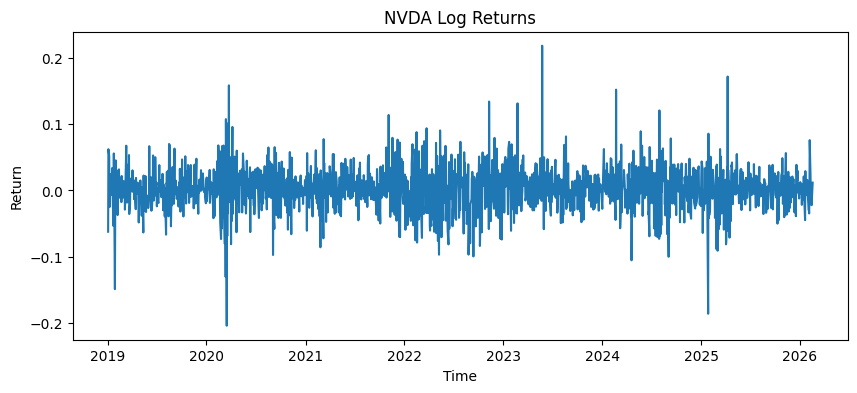

In [69]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("NVDA Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

In [70]:
df = pd.DataFrame(
    {
        "ret": returns.values.flatten()
    },
    index=returns.index
)

The plot shows the daily log returns of NVDA over the sample period. The Returns fluctuate around zero, which is expected since log returns remove long-term price trends and center the series near their mean.

Importantly, the strength of fluctation varies over time, indicating periods of higher and lower volatility. This suggests the presence of time-varying volatility regimes, which motivates my use of a Hidden Markov Model (HMM). In hopes to capture the underlying distributions governing market behavior.

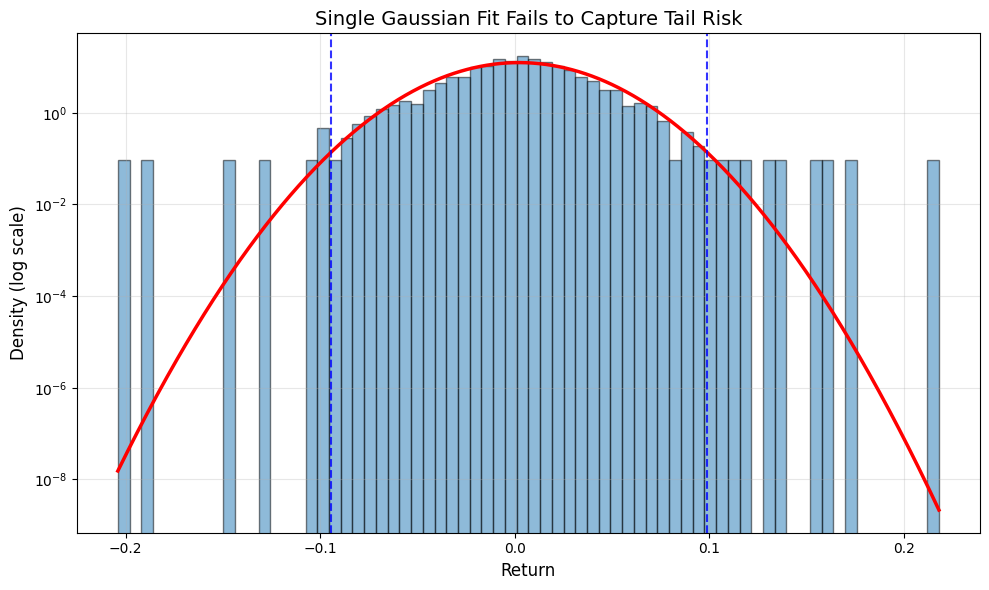

In [ ]:
all_returns = df["ret"]

mu_all = all_returns.mean()
sigma_all = all_returns.std(ddof=1)

x = np.linspace(all_returns.min(), all_returns.max(), 1000)
pdf_all = norm.pdf(x, mu_all, sigma_all)

k = 3
left_tail = mu_all - k * sigma_all
right_tail = mu_all + k * sigma_all

plt.figure(figsize=(10,6))

plt.hist(
    all_returns,
    bins=70,
    density=True,
    alpha=0.5,
    edgecolor="black",
)

plt.plot(
    x,
    pdf_all,
    color="red",
    linewidth=2.5,
)

plt.axvline(left_tail, color="blue", linestyle="--", alpha=0.8)
plt.axvline(right_tail, color="blue", linestyle="--", alpha=0.8)

plt.yscale("log")

plt.title("Single Gaussian Fit Fails to Capture Tail Risk", fontsize=14)
plt.xlabel("Return", fontsize=12)
plt.ylabel("Density (log scale)", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
actual_tail = np.mean(np.abs(all_returns - mu_all) > k * sigma_all)
expected_tail = 2 * (1 - norm.cdf(k))
print("AT", actual_tail, "ET", expected_tail)


AT 0.0111731843575419 ET 0.002699796063260207


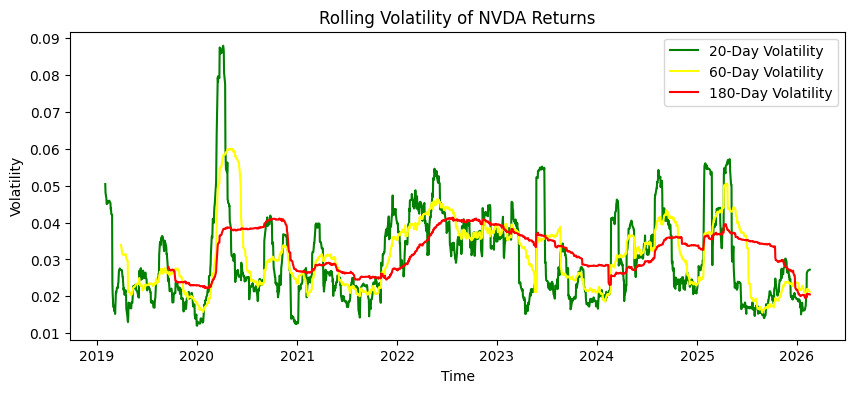

In [72]:
rolling_vol_30 = returns.rolling(20).std()
rolling_vol_50 = returns.rolling(60).std()
rolling_vol_100 = returns.rolling(180).std()

plt.figure(figsize=(10,4))

plt.plot(rolling_vol_30, label="20-Day Volatility", color="green")
plt.plot(rolling_vol_50, label="60-Day Volatility", color="yellow")
plt.plot(rolling_vol_100, label="180-Day Volatility", color="red")

plt.title("Rolling Volatility of NVDA Returns")
plt.xlabel("Time")
plt.ylabel("Volatility")

plt.legend()
plt.show()

Looks cool, could have some cool explanation 

In [73]:
results = []
best_models = {}

for K in range(1,6):

    scores = []
    models = []

    print("\nTesting K =", K)

    for i in range(20):

        ran_state = random.randint(1,10000)

        model = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=2000,
            tol=1e-3,
            random_state=ran_state
        )

        model.fit(X)

        score = model.score(X)

        scores.append(score)
        models.append(model)


    best_idx = np.argmax(scores)
    best_model = models[best_idx]
    best_score = scores[best_idx]

    worst_score = min(scores)
    diff = best_score - worst_score

    print("Best score:", best_score)
    print("Worst score:", worst_score)
    print("Difference:", diff)

    best_models[K] = best_model

    results.append({
        "K":K,
        "best_logL":best_score,
        "worst_logL":worst_score,
        "diff":diff
    })


Testing K = 1
Best score: 3610.8435635688043
Worst score: 3610.8435635688043
Difference: 0.0

Testing K = 2
Best score: 3766.995933591868
Worst score: 3766.993176794362
Difference: 0.0027567975057536387

Testing K = 3
Best score: 3790.4032081718155
Worst score: 3767.6005640769195
Difference: 22.802644094896095

Testing K = 4
Best score: 3797.496290699691
Worst score: 3765.968373881429
Difference: 31.52791681826193

Testing K = 5


/Users/nicholasbooker/Downloads/Quant/Market-Regimes-HMM/.venv/lib/python3.12/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have ze

ValueError: startprob_ must sum to 1 (got nan)

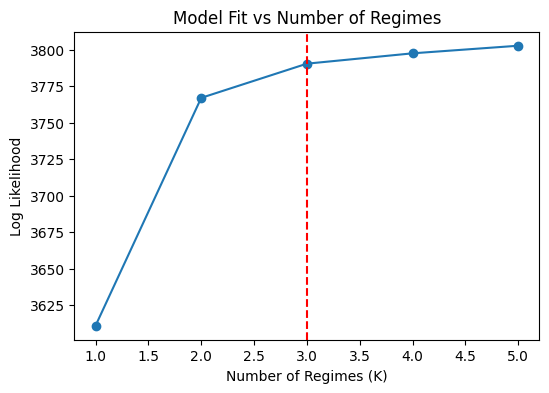

In [ ]:
Ks = [r["K"] for r in results]
scores = [r["best_logL"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, scores, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Log Likelihood")
plt.title("Model Fit vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

The plot shows the log-likelihood of the Hidden Markov Model as a function of the number of regimes K. As expected, the log-likelihood increases as additional regimes are introduced, since a more flexible model can better capture more structure in the data.

However, the marginal improvement in log-likelihood begins to diminish after K = 3. The sharp increase from K=1 to K=2 and the continued improvement at K=3 indicate that multiple volatility regimes are present in the return series. Beyond this point, the gains in model fit become relatively small. I believe this suggest that additional regimes primarily capture noise rather than meaningful structure.

The dashed vertical line highlights K=3 as the selected model (# of regimes). 

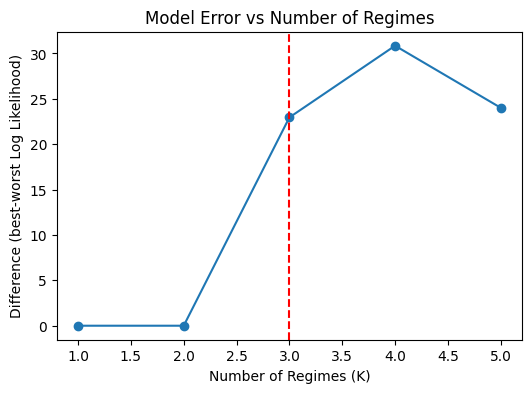

In [ ]:
Ks = [r["K"] for r in results]
diff = [r["diff"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, diff, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Difference (best-worst Log Likelihood)")
plt.title("Model Error vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

This visualization shows that K=3 is not just best fit based on log likehood. But it's also a strong canddidate for the 20 iterations of model fitting that regular agreed on the confident of the log likelhood as they are different by almost nothing which the other number of regimes also showed.

The reason we need 20 iterations for each model, is because the EM Algoirthm is choosing a random max, which means, sometimes it doesn't find the Global max everytime through the 2000 iterations that it gets to converge. (We can wonder what will happen if we were to increase this more but from computation we'll keep it like this for now)

In [ ]:
K = 3

model = best_models[K]

print("Final Model Score:", model.score(X))
print("Converged:", model.monitor_.converged)

Final Model Score: 3790.428351715005
Converged: True


Now that we have fit our data on the model with 3 regimes. Hopefully, we may also caputre different techniques to predict and how the prediction looks overall.

In [ ]:
transmat = model.transmat_
startprob = model.startprob_
print("Transition Matrix:")
print(transmat)
print("Start Probabilities:")
print(startprob)

Transition Matrix:
[[0.95558138 0.02161063 0.022808  ]
 [0.00626543 0.98736639 0.00636818]
 [0.580171   0.02293977 0.39688924]]
Start Probabilities:
[2.40092783e-04 1.49789315e-67 9.99759907e-01]


In [ ]:
mu = model.means_.flatten()
sigma = np.sqrt(model.covars_.flatten())

order = np.argsort(sigma)

labels = ["Low", "Med", "High"]

In [ ]:
state_to_regime = {
    state_idx: labels[i]
    for i, state_idx in enumerate(order)
}

state_to_regime

{np.int64(1): 'Low', np.int64(0): 'Med', np.int64(2): 'High'}

In [ ]:
states = model.predict(X)

print(states[:10])

[2 0 0 0 0 0 0 0 0 0]


In [ ]:
df["state"] = states

df["regime"] = df["state"].map(state_to_regime)

print(state_to_regime)
print(df.head())

{np.int64(1): 'Low', np.int64(0): 'Med', np.int64(2): 'High'}
                 ret  state regime
Date                              
2019-01-03 -0.062319      2   High
2019-01-04  0.062099      0    Med
2019-01-07  0.051587      0    Med
2019-01-08 -0.025210      0    Med
2019-01-09  0.019476      0    Med


In [ ]:
summary = df.groupby("regime")["ret"].agg(
    mean="mean",
    std="std",
    var="var",
    count="count",
    min="min",
    max="max"
)

print(summary)

            mean       std       var  count       min       max
regime                                                         
High    0.026940  0.142744  0.020376     17 -0.203979  0.218088
Low     0.003238  0.022303  0.000497   1130 -0.066696  0.081316
Med    -0.000177  0.038501  0.001482    643 -0.105412  0.120553


Create a Observation BoxPlot and a Frequency Histrogram

(How my model aligns with events like COVID, 2008, 2022, AI Boom) Or we actaully getting anything out of this model

Heatmap of Persistence since or do a graph visual again (where my diagonal would show persistence)

The expected time between regimes, maybe between all regimes relationship with each other
(Also, how long does it just natural last)

Within certain time period, does persistence seem to overcompensate, causing regime switching to go beyond the typical

/var/folders/m3/55vn77px58s9m__ndct5d9w80000gn/T/ipykernel_5899/4195372514.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


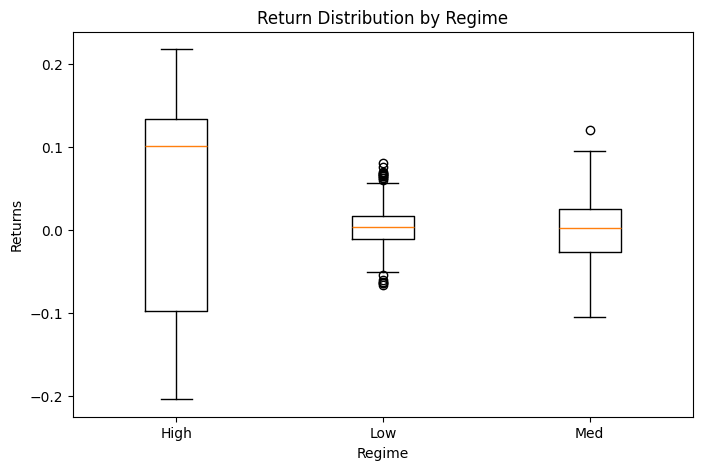

In [ ]:
order = sorted(df["regime"].unique())

data = [df[df["regime"] == r]["ret"] for r in order]

plt.figure(figsize=(8,5))

plt.boxplot(data, labels=order)

plt.title("Return Distribution by Regime")
plt.xlabel("Regime")
plt.ylabel("Returns")

plt.show()

In [ ]:
print(order)
print(data)
print(len(data))

['High', 'Low', 'Med']
[Date
2019-01-03   -0.062319
2019-01-28   -0.148785
2020-03-12   -0.130527
2020-03-13    0.107420
2020-03-16   -0.203979
2020-03-17    0.100987
2020-03-24    0.158340
2020-09-03   -0.097365
2021-02-25   -0.085752
2021-11-04    0.113706
2022-11-10    0.133912
2023-02-23    0.131216
2023-05-25    0.218088
2024-02-22    0.151870
2025-01-27   -0.185946
2025-01-28    0.085497
2025-04-09    0.171621
Name: ret, dtype: float64, Date
2019-02-01    0.006794
2019-02-04    0.030284
2019-02-05    0.005148
2019-02-06    0.020136
2019-02-07   -0.037152
                ...   
2026-02-10   -0.007924
2026-02-11    0.007977
2026-02-12   -0.016499
2026-02-13   -0.022340
2026-02-17    0.011746
Name: ret, Length: 1130, dtype: float64, Date
2019-01-04    0.062099
2019-01-07    0.051587
2019-01-08   -0.025210
2019-01-09    0.019476
2019-01-10    0.018416
                ...   
2025-04-21   -0.046177
2025-04-22    0.020225
2025-04-23    0.037901
2025-04-24    0.035578
2025-04-25    0.042

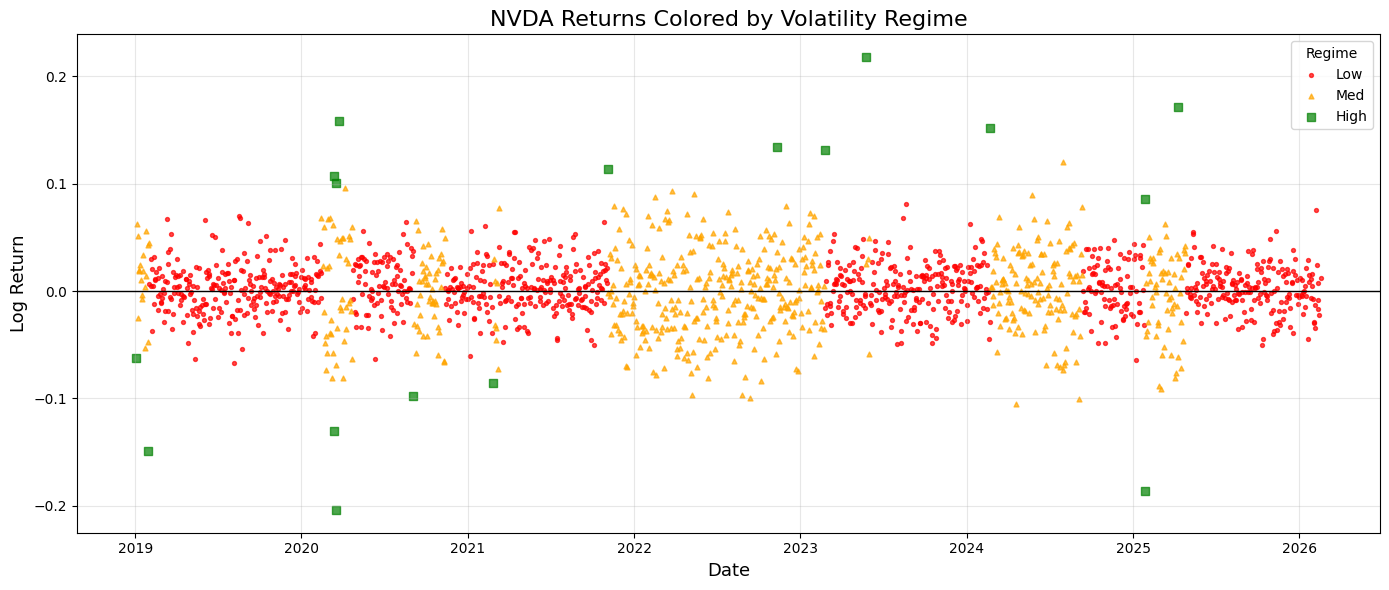

In [ ]:

colors = {
    "Low": "red",
    "Med": "orange",
    "High": "green"
}

markers = {
    "Low": "o",
    "Med": "^",
    "High": "s"
}

sizes = {
    "Low": 8,
    "Med": 12,
    "High": 28
}

plt.figure(figsize=(14,6))

for regime in ["Low", "Med", "High"]:
    subset = df[df["regime"] == regime]

    plt.scatter(
        subset.index,
        subset["ret"],
        color=colors[regime],
        marker=markers[regime],
        label=regime,
        s=sizes[regime],
        alpha=0.7
    )

plt.axhline(0, color="black", linewidth=1)

plt.title("NVDA Returns Colored by Volatility Regime", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Log Return", fontsize=13)

plt.legend(title="Regime")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Expected Duration in each regime

Checking what those outliers mean

Show regimes on the price chart

Main points views

Is my Vol clustering?

Persistence of my regimes (Just go back to my heatmap of the transition probability)

Tail Risk

Nonstationarity

(What kind of tool is this?) What other methods people used (predict, interpretaion, or what are we seeing)

- Numerical Methods to understand vol in Markets --> Ans: with HMM


What other methods do people use. Is that different information that's being captured.

April 22nd Final Poster Submission


Presentation 3 on April 23rd


### What do our predict observations look under its respected regime distrubution curve...

### Assigning a color default

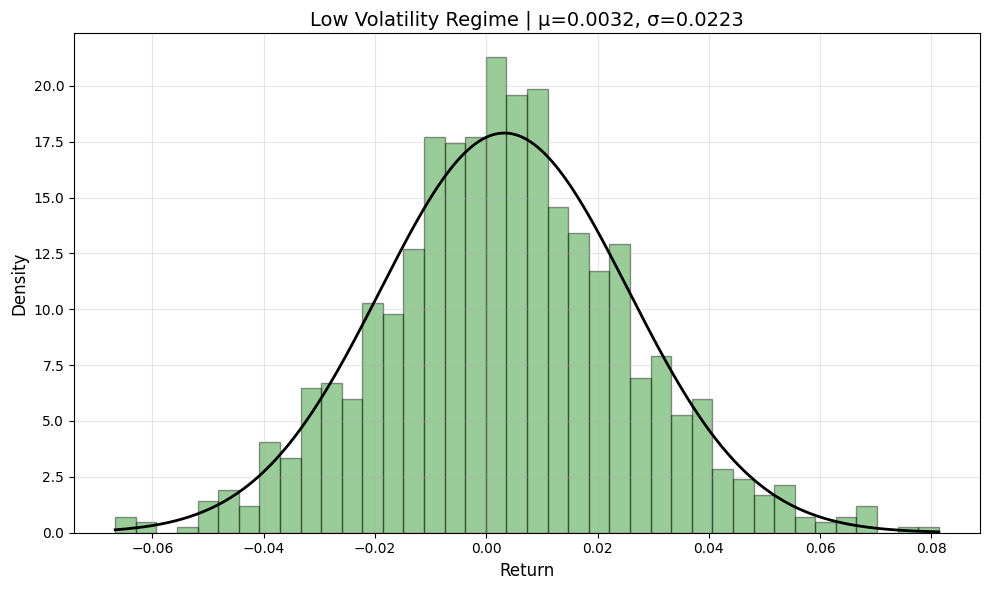

In [ ]:
chosen_regime = "Low"

mu_reg = summary.loc[chosen_regime]["mean"]
sigma_reg = summary.loc[chosen_regime]["std"]

x = np.linspace(df[df["regime"] == chosen_regime]["ret"].min(), df[df["regime"] == chosen_regime]["ret"].max(), 1000)

subset = df[df["regime"] == chosen_regime]["ret"]

plt.figure(figsize=(10,6))

plt.hist(
    subset,
    bins=40,
    density=True,
    alpha=0.4,
    color= "green",
    edgecolor="black"
)

pdf = norm.pdf(x, mu_reg, sigma_reg)

plt.plot(x, pdf, color="black", linewidth=2)

plt.title(f"{chosen_regime} Volatility Regime | μ={mu_reg:.4f}, σ={sigma_reg:.4f}", fontsize=14)
plt.xlabel("Return", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

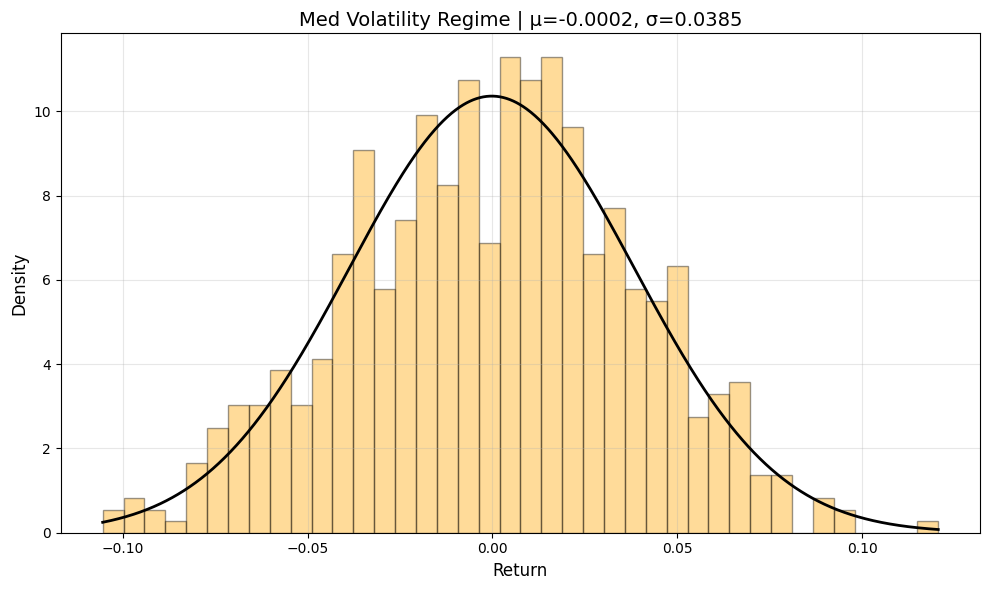

In [ ]:
chosen_regime = "Med"

mu_reg = summary.loc[chosen_regime]["mean"]
sigma_reg = summary.loc[chosen_regime]["std"]

x = np.linspace(df[df["regime"] == chosen_regime]["ret"].min(), df[df["regime"] == chosen_regime]["ret"].max(), 1000)

subset = df[df["regime"] == chosen_regime]["ret"]

plt.figure(figsize=(10,6))

plt.hist(
    subset,
    bins=40,
    density=True,
    alpha=0.4,
    color= "orange",
    edgecolor="black"
)

pdf = norm.pdf(x, mu_reg, sigma_reg)

plt.plot(x, pdf, color="black", linewidth=2)

plt.title(f"{chosen_regime} Volatility Regime | μ={mu_reg:.4f}, σ={sigma_reg:.4f}", fontsize=14)
plt.xlabel("Return", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

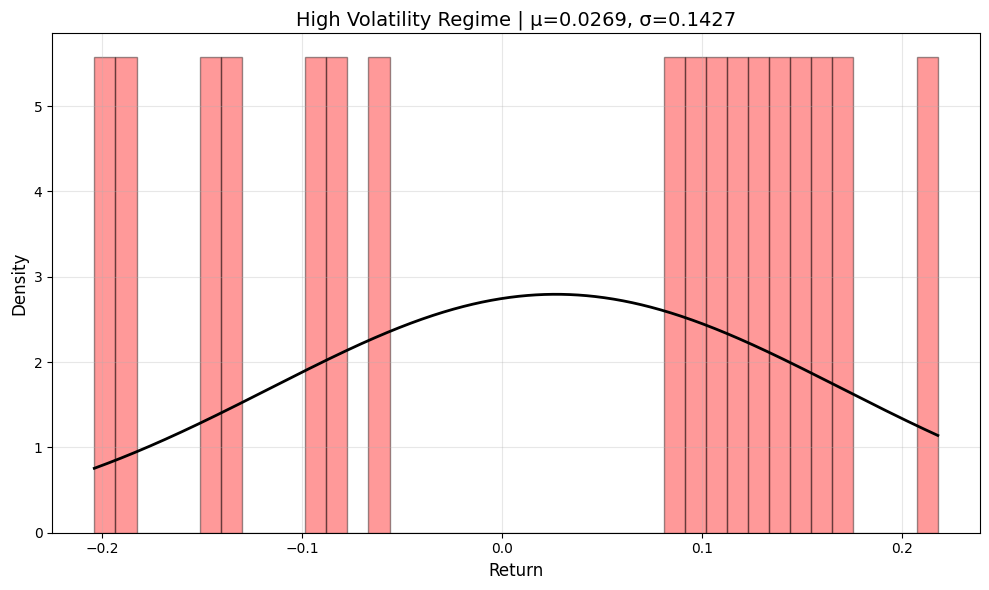

In [ ]:
chosen_regime = "High"

mu_reg = summary.loc[chosen_regime]["mean"]
sigma_reg = summary.loc[chosen_regime]["std"]

x = np.linspace(df[df["regime"] == chosen_regime]["ret"].min(), df[df["regime"] == chosen_regime]["ret"].max(), 1000)

subset = df[df["regime"] == chosen_regime]["ret"]

plt.figure(figsize=(10,6))

plt.hist(
    subset,
    bins=40,
    density=True,
    alpha=0.4,
    color= "red",
    edgecolor="black"
)

pdf = norm.pdf(x, mu_reg, sigma_reg)

plt.plot(x, pdf, color="black", linewidth=2)

plt.title(f"{chosen_regime} Volatility Regime | μ={mu_reg:.4f}, σ={sigma_reg:.4f}", fontsize=14)
plt.xlabel("Return", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
summary["pct"] = (100 * summary["count"] / summary["count"].sum()).round(2)

summary

,mean,std,var,count,min,max,pct
regime,,,,,,,
High,0.026940,0.142744,0.020376,17,-0.203979,0.218088,0.95
Low,0.003238,0.022303,0.000497,1130,-0.066696,0.081316,63.13
Med,-0.000177,0.038501,0.001482,643,-0.105412,0.120553,35.92


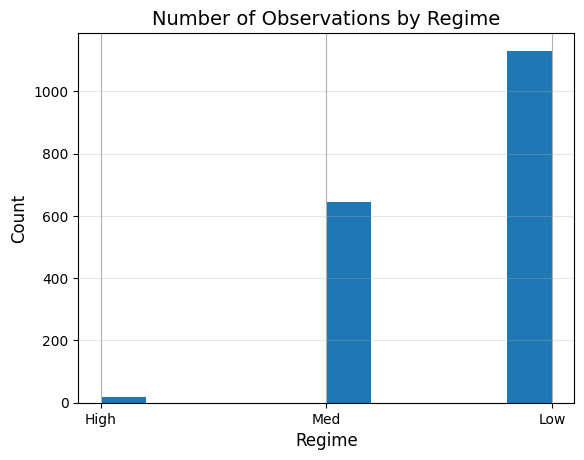

In [ ]:
df["regime"].hist()
plt.title("Number of Observations by Regime", fontsize=14)
plt.xlabel("Regime", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
transition_matrix = model.transmat_
transition_matrix

array([[0.95558138, 0.02161063, 0.022808  ],
       [0.00626543, 0.98736639, 0.00636818],
       [0.580171  , 0.02293977, 0.39688924]])

In [ ]:
state_to_regime[0], state_to_regime[1], state_to_regime[2]

('Med', 'Low', 'High')

In [ ]:
summary

,mean,std,var,count,min,max,pct
regime,,,,,,,
High,0.026940,0.142744,0.020376,17,-0.203979,0.218088,0.95
Low,0.003238,0.022303,0.000497,1130,-0.066696,0.081316,63.13
Med,-0.000177,0.038501,0.001482,643,-0.105412,0.120553,35.92


# Expected Duration

In [ ]:
expected_duration = (1 / (1 - np.diag(transmat))).round(2)
expected_duration


array([22.51, 79.15,  1.66])

- Check on outliers and each observation of based on Expectation

May not work on April 9th for Advisor Meeting